# Street Vision
Semantic segmentation overlays on street photography using SegFormer (ADE20K).

## Cell 1 — Install Dependencies

In [94]:
%pip install transformers torch torchvision pillow opencv-python numpy matplotlib scipy easyocr


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import shutil
from pathlib import Path

OUTPUT_FOLDERS = [
    "masks", "output",
    "masks_cityscapes", "output_cityscapes",
    "masks_mapillary", "output_mapillary",
    "ocr_results", "clip_results", "clip_isolated",
    "layered",
]

for folder in OUTPUT_FOLDERS:
    p = Path(folder)
    if p.exists():
        shutil.rmtree(p)
        print(f"Deleted {folder}/")
    else:
        print(f"{folder}/ — not found, skipping.")

print("\nAll output folders cleaned.")

## Clean Up Output Folders
Run this cell to delete all generated images before re-running the notebook.

## Cell 2 — Imports

In [95]:
import os
from pathlib import Path

import numpy as np
import cv2
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch

IMAGES_DIR = Path("images")
MASKS_DIR = Path("masks")
OUTPUT_DIR = Path("output")

MASKS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_NAME = "nvidia/segformer-b5-finetuned-ade-640-640"
BLEND_ALPHA = 0.5

print("Imports done.")

Imports done.


## Cell 3 — Load Model

In [96]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

image_processor = SegformerImageProcessor.from_pretrained(MODEL_NAME)
model = SegformerForSemanticSegmentation.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"Model loaded on {device}.")

Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 1567.72it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]             


Model loaded on mps.


## Cell 4 — Run Segmentation

In [97]:
# ADE20K 150-class color palette
ADE20K_PALETTE = np.array([
    [120, 120, 120],  # 0  wall
    [180, 120, 120],  # 1  building
    [6, 230, 230],    # 2  sky
    [80, 50, 50],     # 3  floor
    [4, 200, 3],      # 4  tree
    [120, 120, 80],   # 5  ceiling
    [140, 140, 140],  # 6  road
    [204, 5, 255],    # 7  bed
    [230, 230, 230],  # 8  windowpane
    [4, 250, 7],      # 9  grass
    [224, 5, 255],    # 10 cabinet
    [235, 255, 7],    # 11 sidewalk
    [150, 5, 61],     # 12 person
    [120, 120, 70],   # 13 earth
    [8, 255, 51],     # 14 door
    [255, 6, 82],     # 15 table
    [143, 255, 140],  # 16 mountain
    [204, 255, 4],    # 17 plant
    [255, 51, 7],     # 18 curtain
    [204, 70, 3],     # 19 chair
    [0, 102, 200],    # 20 car
    [61, 230, 250],   # 21 water
    [255, 6, 51],     # 22 painting
    [11, 102, 255],   # 23 sofa
    [255, 7, 71],     # 24 shelf
    [255, 9, 224],    # 25 house
    [9, 7, 230],      # 26 sea
    [220, 220, 220],  # 27 mirror
    [255, 9, 92],     # 28 rug
    [112, 9, 255],    # 29 field
    [8, 255, 214],    # 30 armchair
    [7, 255, 224],    # 31 seat
    [255, 184, 6],    # 32 fence
    [10, 255, 71],    # 33 desk
    [255, 41, 10],    # 34 rock
    [7, 255, 255],    # 35 wardrobe
    [224, 255, 8],    # 36 lamp
    [102, 8, 255],    # 37 bathtub
    [255, 61, 6],     # 38 railing
    [255, 194, 7],    # 39 cushion
    [255, 122, 8],    # 40 base
    [0, 255, 20],     # 41 box
    [255, 8, 41],     # 42 column
    [255, 5, 153],    # 43 signboard
    [6, 51, 255],     # 44 chest of drawers
    [235, 12, 255],   # 45 counter
    [160, 150, 20],   # 46 sand
    [0, 163, 255],    # 47 sink
    [140, 140, 140],  # 48 skyscraper
    [250, 10, 15],    # 49 fireplace
    [20, 255, 0],     # 50 refrigerator
    [31, 255, 0],     # 51 grandstand
    [255, 31, 0],     # 52 path
    [255, 224, 0],    # 53 stairs
    [153, 255, 0],    # 54 runway
    [0, 0, 255],      # 55 case
    [255, 71, 0],     # 56 pool table
    [0, 235, 255],    # 57 pillow
    [0, 173, 255],    # 58 screen door
    [31, 0, 255],     # 59 stairway
    [11, 200, 200],   # 60 river
    [255, 82, 0],     # 61 bridge
    [0, 255, 245],    # 62 bookcase
    [0, 61, 255],     # 63 blind
    [0, 255, 112],    # 64 coffee table
    [0, 255, 133],    # 65 toilet
    [255, 0, 0],      # 66 flower
    [255, 163, 0],    # 67 book
    [255, 102, 0],    # 68 hill
    [194, 255, 0],    # 69 bench
    [0, 143, 255],    # 70 countertop
    [51, 255, 0],     # 71 stove
    [0, 82, 255],     # 72 palm
    [0, 255, 41],     # 73 kitchen island
    [0, 255, 173],    # 74 computer
    [10, 0, 255],     # 75 swivel chair
    [173, 255, 0],    # 76 boat
    [0, 255, 153],    # 77 bar
    [255, 92, 0],     # 78 arcade machine
    [255, 0, 255],    # 79 hovel
    [255, 0, 245],    # 80 bus
    [255, 0, 102],    # 81 towel
    [255, 173, 0],    # 82 light
    [255, 0, 20],     # 83 truck
    [255, 184, 184],  # 84 tower
    [0, 31, 255],     # 85 chandelier
    [0, 255, 61],     # 86 awning
    [0, 71, 255],     # 87 streetlight
    [255, 0, 204],    # 88 booth
    [0, 255, 194],    # 89 television
    [0, 255, 82],     # 90 airplane
    [0, 10, 255],     # 91 dirt track
    [0, 112, 255],    # 92 apparel
    [51, 0, 255],     # 93 pole
    [0, 194, 255],    # 94 land
    [0, 122, 255],    # 95 bannister
    [0, 255, 163],    # 96 escalator
    [255, 153, 0],    # 97 ottoman
    [0, 255, 10],     # 98 bottle
    [255, 112, 0],    # 99 buffet
    [143, 255, 0],    # 100 poster
    [82, 0, 255],     # 101 stage
    [163, 255, 0],    # 102 van
    [255, 235, 0],    # 103 ship
    [8, 184, 170],    # 104 fountain
    [133, 0, 255],    # 105 conveyer belt
    [0, 255, 92],     # 106 canopy
    [184, 0, 255],    # 107 washer
    [255, 0, 31],     # 108 plaything
    [0, 184, 255],    # 109 swimming pool
    [0, 214, 255],    # 110 stool
    [255, 0, 112],    # 111 barrel
    [92, 255, 0],     # 112 basket
    [0, 224, 255],    # 113 waterfall
    [112, 224, 255],  # 114 tent
    [70, 184, 160],   # 115 bag
    [163, 0, 255],    # 116 minibike
    [153, 0, 255],    # 117 cradle
    [71, 255, 0],     # 118 oven
    [255, 0, 163],    # 119 ball
    [255, 204, 0],    # 120 food
    [255, 0, 143],    # 121 step
    [0, 255, 235],    # 122 tank
    [133, 255, 0],    # 123 trade name
    [255, 0, 235],    # 124 microwave
    [245, 0, 255],    # 125 pot
    [255, 0, 122],    # 126 animal
    [255, 245, 0],    # 127 bicycle
    [10, 190, 212],   # 128 lake
    [214, 255, 0],    # 129 dishwasher
    [0, 204, 255],    # 130 screen
    [20, 0, 255],     # 131 blanket
    [255, 255, 0],    # 132 sculpture
    [0, 153, 255],    # 133 hood
    [0, 41, 255],     # 134 sconce
    [0, 255, 204],    # 135 vase
    [41, 0, 255],     # 136 traffic light
    [41, 255, 0],     # 137 tray
    [173, 0, 255],    # 138 ashcan
    [0, 245, 255],    # 139 fan
    [71, 0, 255],     # 140 pier
    [122, 0, 255],    # 141 crt screen
    [0, 255, 184],    # 142 plate
    [0, 92, 255],     # 143 monitor
    [184, 255, 0],    # 144 bulletin board
    [0, 133, 255],    # 145 shower
    [255, 214, 0],    # 146 radiator
    [25, 194, 194],   # 147 glass
    [102, 255, 0],    # 148 clock
    [92, 0, 255],     # 149 flag
], dtype=np.uint8)

image_files = sorted(
    [f for f in IMAGES_DIR.iterdir() if f.suffix.lower() in (".jpg", ".jpeg", ".png")]
)
print(f"Found {len(image_files)} images.")

for i, img_path in enumerate(image_files, 1):
    mask_path = MASKS_DIR / img_path.name
    if mask_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — mask exists, skipping.")
        continue

    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    inputs = image_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=(h, w), mode="bilinear", align_corners=False
    )
    seg_map = upsampled.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)

    color_mask = ADE20K_PALETTE[seg_map]
    Image.fromarray(color_mask).save(mask_path)

    print(f"[{i}/{len(image_files)}] {img_path.name} — done.")

print("Segmentation complete.")

Found 2 images.
[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — done.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — done.
Segmentation complete.


## Cell 5 — Blend Images

In [98]:
for i, img_path in enumerate(image_files, 1):
    output_path = OUTPUT_DIR / img_path.name
    if output_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — output exists, skipping.")
        continue

    original = cv2.imread(str(img_path))
    mask = cv2.imread(str(MASKS_DIR / img_path.name))

    blended = cv2.addWeighted(original, BLEND_ALPHA, mask, 1 - BLEND_ALPHA, 0)
    cv2.imwrite(str(output_path), blended)

    print(f"[{i}/{len(image_files)}] {img_path.name} — blended.")

print("Blending complete.")

[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — blended.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — blended.
Blending complete.


## Cell 6 — Preview

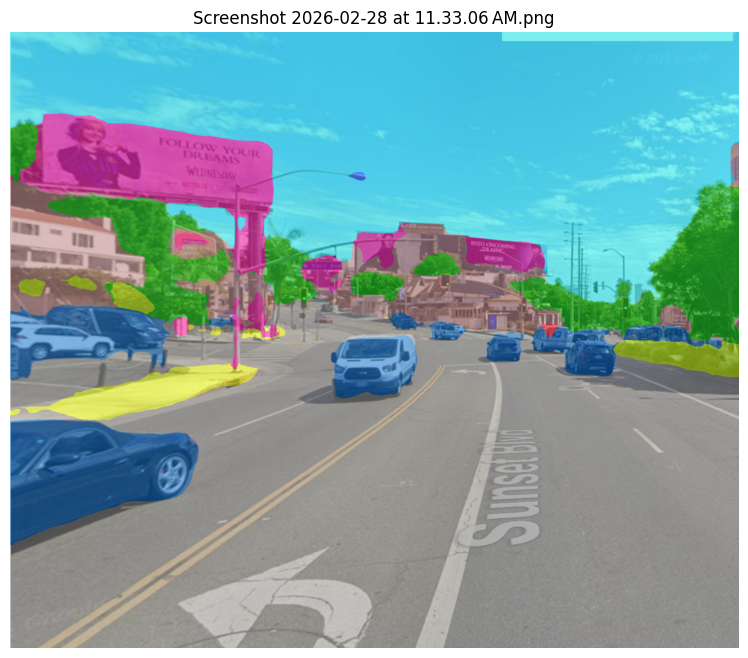

In [99]:
import matplotlib.pyplot as plt

first_output = OUTPUT_DIR / image_files[0].name
preview = cv2.imread(str(first_output))
preview = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(preview)
plt.axis("off")
plt.title(image_files[0].name)
plt.show()

## Cell 7 — Load Cityscapes Model

In [100]:
CITYSCAPES_MODEL = "nvidia/segformer-b3-finetuned-cityscapes-1024-1024"
MASKS_CS_DIR = Path("masks_cityscapes")
OUTPUT_CS_DIR = Path("output_cityscapes")

MASKS_CS_DIR.mkdir(exist_ok=True)
OUTPUT_CS_DIR.mkdir(exist_ok=True)

cs_processor = SegformerImageProcessor.from_pretrained(CITYSCAPES_MODEL)
cs_model = SegformerForSemanticSegmentation.from_pretrained(CITYSCAPES_MODEL).to(device)
cs_model.eval()

print(f"Cityscapes model loaded on {device}.")

Loading weights: 100%|██████████| 644/644 [00:00<00:00, 1707.54it/s, Materializing param=segformer.encoder.patch_embeddings.3.proj.weight]             


Cityscapes model loaded on mps.


## Cell 8 — Run Cityscapes Segmentation

In [101]:
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170, 30],   # traffic light
    [220, 220, 0],    # traffic sign
    [107, 142, 35],   # vegetation
    [152, 251, 152],  # terrain
    [70, 130, 180],   # sky
    [220, 20, 60],    # person
    [255, 0, 0],      # rider
    [0, 0, 142],      # car
    [0, 0, 70],       # truck
    [0, 60, 100],     # bus
    [0, 80, 100],     # train
    [0, 0, 230],      # motorcycle
    [119, 11, 32],    # bicycle
], dtype=np.uint8)

for i, img_path in enumerate(image_files, 1):
    mask_path = MASKS_CS_DIR / img_path.name
    if mask_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — mask exists, skipping.")
        continue

    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    inputs = cs_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = cs_model(**inputs)

    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=(h, w), mode="bilinear", align_corners=False
    )
    seg_map = upsampled.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)

    color_mask = CITYSCAPES_PALETTE[seg_map]
    Image.fromarray(color_mask).save(mask_path)

    print(f"[{i}/{len(image_files)}] {img_path.name} — done.")

print("Cityscapes segmentation complete.")

[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — done.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — done.
Cityscapes segmentation complete.


## Cell 9 — Blend Cityscapes Images

In [102]:
for i, img_path in enumerate(image_files, 1):
    output_path = OUTPUT_CS_DIR / img_path.name
    if output_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — output exists, skipping.")
        continue

    original = cv2.imread(str(img_path))
    mask = cv2.imread(str(MASKS_CS_DIR / img_path.name))

    blended = cv2.addWeighted(original, BLEND_ALPHA, mask, 1 - BLEND_ALPHA, 0)
    cv2.imwrite(str(output_path), blended)

    print(f"[{i}/{len(image_files)}] {img_path.name} — blended.")

print("Cityscapes blending complete.")

[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — blended.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — blended.
Cityscapes blending complete.


## Cell 10 — Preview Cityscapes

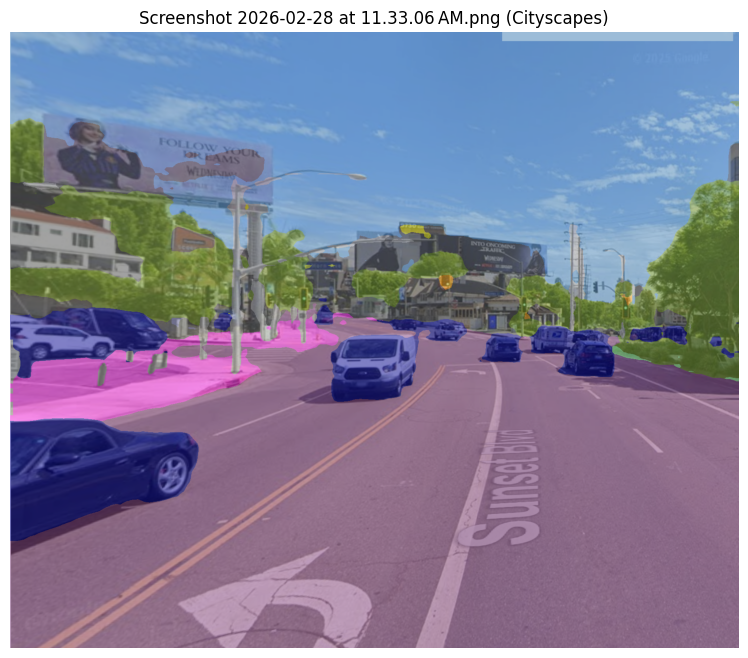

In [103]:
first_cs_output = OUTPUT_CS_DIR / image_files[0].name
preview_cs = cv2.imread(str(first_cs_output))
preview_cs = cv2.cvtColor(preview_cs, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(preview_cs)
plt.axis("off")
plt.title(f"{image_files[0].name} (Cityscapes)")
plt.show()

## Cell 11 — Load Mapillary Vistas Model

In [104]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

MAPILLARY_MODEL = "facebook/mask2former-swin-large-mapillary-vistas-semantic"
MASKS_MV_DIR = Path("masks_mapillary")
OUTPUT_MV_DIR = Path("output_mapillary")

MASKS_MV_DIR.mkdir(exist_ok=True)
OUTPUT_MV_DIR.mkdir(exist_ok=True)

mv_processor = AutoImageProcessor.from_pretrained(MAPILLARY_MODEL)
mv_model = Mask2FormerForUniversalSegmentation.from_pretrained(MAPILLARY_MODEL).to(device)
mv_model.eval()

print(f"Mapillary Vistas model loaded on {device}.")

Loading weights: 100%|██████████| 782/782 [00:00<00:00, 1446.63it/s, Materializing param=model.transformer_module.queries_features.weight]                                                       


Mapillary Vistas model loaded on mps.


## Cell 12 — Run Mapillary Vistas Segmentation

In [105]:
# Mapillary Vistas 65-class color palette
MAPILLARY_PALETTE = np.array([
    [165,  42,  42],   #  0  Bird
    [  0, 192,   0],   #  1  Ground Animal
    [196, 196, 196],   #  2  Curb
    [190, 153, 153],   #  3  Fence
    [180, 165, 180],   #  4  Guard Rail
    [102, 102, 156],   #  5  Barrier
    [102, 102, 156],   #  6  Wall
    [128,  64, 255],   #  7  Bike Lane
    [140, 140, 200],   #  8  Crosswalk - Plain
    [170, 170, 170],   #  9  Curb Cut
    [250, 170, 160],   # 10  Parking
    [ 96,  96,  96],   # 11  Pedestrian Area
    [230, 150, 140],   # 12  Rail Track
    [128,  64, 128],   # 13  Road
    [110, 110, 110],   # 14  Service Lane
    [244,  35, 232],   # 15  Sidewalk
    [150, 100, 100],   # 16  Bridge
    [ 70,  70,  70],   # 17  Building
    [150, 120,  90],   # 18  Tunnel
    [220,  20,  60],   # 19  Person
    [255,   0,   0],   # 20  Bicyclist
    [255,   0,   0],   # 21  Motorcyclist
    [255,   0,   0],   # 22  Other Rider
    [200, 128, 128],   # 23  Lane Marking - Crosswalk
    [255, 255, 255],   # 24  Lane Marking - General
    [ 64, 170,  64],   # 25  Mountain
    [128,  64,  64],   # 26  Sand
    [ 70, 130, 180],   # 27  Sky
    [255, 255, 255],   # 28  Snow
    [152, 251, 152],   # 29  Terrain
    [107, 142,  35],   # 30  Vegetation
    [  0, 170,  30],   # 31  Water
    [255, 255, 128],   # 32  Banner
    [250,   0,  30],   # 33  Bench
    [  0,   0,   0],   # 34  Bike Rack
    [220, 220, 220],   # 35  Billboard
    [170, 170, 170],   # 36  Catch Basin
    [222,  40,  40],   # 37  CCTV Camera
    [100, 170,  30],   # 38  Fire Hydrant
    [ 40,  40,  40],   # 39  Junction Box
    [ 33,  33,  33],   # 40  Mailbox
    [170, 170, 170],   # 41  Manhole
    [  0,   0, 142],   # 42  Phone Booth
    [170, 170, 170],   # 43  Pothole
    [210, 170, 100],   # 44  Street Light
    [153, 153, 153],   # 45  Pole
    [128, 128, 128],   # 46  Traffic Sign Frame
    [  0,   0, 142],   # 47  Utility Pole
    [250, 170,  30],   # 48  Traffic Light
    [192, 192, 192],   # 49  Traffic Sign (Back)
    [220, 220,   0],   # 50  Traffic Sign (Front)
    [180, 165, 180],   # 51  Trash Can
    [119,  11,  32],   # 52  Bicycle
    [  0,   0, 142],   # 53  Boat
    [  0,  60, 100],   # 54  Bus
    [  0,   0, 142],   # 55  Car
    [  0,   0,  90],   # 56  Caravan
    [  0,   0, 230],   # 57  Motorcycle
    [  0,  80, 100],   # 58  On Rails
    [128,  64,  64],   # 59  Other Vehicle
    [  0,   0, 110],   # 60  Trailer
    [  0,   0,  70],   # 61  Truck
    [  0,   0, 192],   # 62  Wheeled Slow
    [ 32,  32,  32],   # 63  Car Mount
    [  0,   0,   0],   # 64  Ego Vehicle
], dtype=np.uint8)

for i, img_path in enumerate(image_files, 1):
    mask_path = MASKS_MV_DIR / img_path.name
    if mask_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — mask exists, skipping.")
        continue

    image = Image.open(img_path).convert("RGB")

    inputs = mv_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = mv_model(**inputs)

    seg_map = mv_processor.post_process_semantic_segmentation(
        outputs, target_sizes=[image.size[::-1]]
    )[0].cpu().numpy().astype(np.uint8)

    color_mask = MAPILLARY_PALETTE[seg_map]
    Image.fromarray(color_mask).save(mask_path)

    print(f"[{i}/{len(image_files)}] {img_path.name} — done.")

print("Mapillary Vistas segmentation complete.")

[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — done.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — done.
Mapillary Vistas segmentation complete.


## Cell 13 — Blend Mapillary Images

In [106]:
for i, img_path in enumerate(image_files, 1):
    output_path = OUTPUT_MV_DIR / img_path.name
    if output_path.exists():
        print(f"[{i}/{len(image_files)}] {img_path.name} — output exists, skipping.")
        continue

    original = cv2.imread(str(img_path))
    mask = cv2.imread(str(MASKS_MV_DIR / img_path.name))

    blended = cv2.addWeighted(original, BLEND_ALPHA, mask, 1 - BLEND_ALPHA, 0)
    cv2.imwrite(str(output_path), blended)

    print(f"[{i}/{len(image_files)}] {img_path.name} — blended.")

print("Mapillary blending complete.")

[1/2] Screenshot 2026-02-28 at 11.33.06 AM.png — blended.
[2/2] Screenshot 2026-02-28 at 11.34.13 AM.png — blended.
Mapillary blending complete.


## Cell 14 — Preview Mapillary

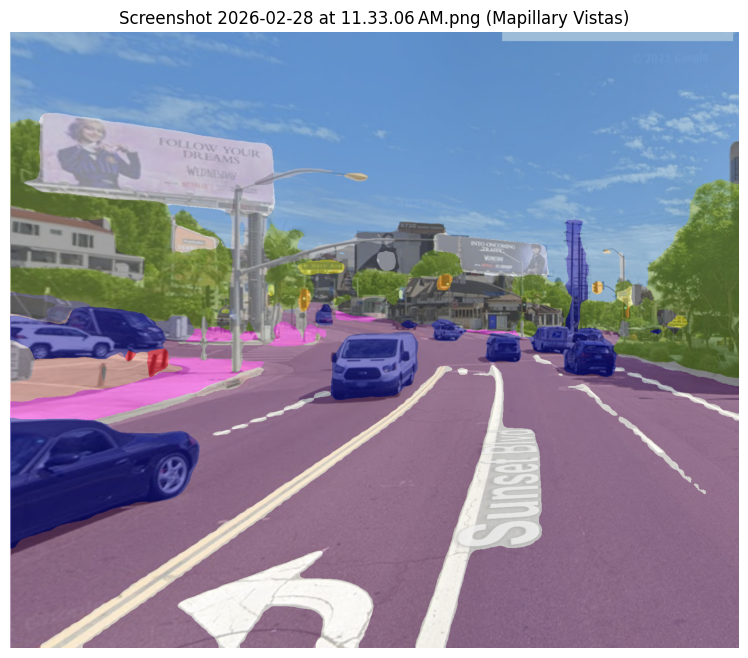

In [107]:
first_mv_output = OUTPUT_MV_DIR / image_files[0].name
preview_mv = cv2.imread(str(first_mv_output))
preview_mv = cv2.cvtColor(preview_mv, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(preview_mv)
plt.axis("off")
plt.title(f"{image_files[0].name} (Mapillary Vistas)")
plt.show()

## Cell 15 — OCR on Sign Regions

In [108]:
import easyocr

# Sign-related class IDs from Mapillary Vistas
SIGN_CLASSES = {32, 35, 46, 49, 50}  # Banner, Billboard, Traffic Sign Frame, Traffic Sign (Back/Front)
SIGN_NAMES = {
    32: "Banner", 35: "Billboard", 46: "Traffic Sign Frame",
    49: "Traffic Sign (Back)", 50: "Traffic Sign (Front)",
}

reader = easyocr.Reader(["en"], gpu=torch.cuda.is_available())

OCR_DIR = Path("ocr_results")
OCR_DIR.mkdir(exist_ok=True)

for img_path in image_files:
    mask_path = MASKS_MV_DIR / img_path.name
    mask_img = np.array(Image.open(mask_path))
    original = cv2.imread(str(img_path))
    img_h, img_w = original.shape[:2]

    # Rebuild seg_map from saved color mask by matching palette colors
    seg_map = np.zeros(mask_img.shape[:2], dtype=np.uint8)
    for cls_id in SIGN_CLASSES:
        color = MAPILLARY_PALETTE[cls_id]
        match = np.all(mask_img == color, axis=-1)
        seg_map[match] = cls_id

    # Create binary mask of all sign pixels
    sign_mask = np.isin(seg_map, list(SIGN_CLASSES))

    if not sign_mask.any():
        print(f"{img_path.name}: no sign regions detected.")
        continue

    # Find contours of sign regions
    sign_uint8 = sign_mask.astype(np.uint8) * 255
    contours, _ = cv2.findContours(sign_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    annotated = original.copy()
    print(f"\n{img_path.name}: found {len(contours)} sign region(s)")

    for j, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)
        print(f"  Region {j+1}: {w}x{h} at ({x},{y})")

        # Skip tiny regions
        if w < 15 or h < 15:
            print(f"    skipped (too small)")
            continue

        # Add padding around the crop for better OCR context
        pad = max(w, h) // 4
        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(img_w, x + w + pad)
        y2 = min(img_h, y + h + pad)
        sign_crop = original[y1:y2, x1:x2]

        # Run OCR on the padded crop
        results = reader.readtext(sign_crop)

        if not results:
            print(f"    no text detected")
            continue

        for (bbox, text, conf) in results:
            print(f"    [{conf:.2f}] \"{text}\"")

            # Draw box and text on annotated image
            cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(annotated, f"{text} ({conf:.0%})", (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Also run OCR on the full image to catch anything the segmentation missed
    print(f"\n  Full-image OCR:")
    full_results = reader.readtext(original)
    for (bbox, text, conf) in full_results:
        if conf < 0.1:
            continue
        print(f"    [{conf:.2f}] \"{text}\"")
        # Draw in blue for full-image detections
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(annotated, [pts], True, (255, 0, 0), 2)
        cv2.putText(annotated, text, (pts[0][0], pts[0][1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

    # Save annotated image
    cv2.imwrite(str(OCR_DIR / img_path.name), annotated)

print(f"\nAnnotated images saved to {OCR_DIR}/")

Using CPU. Note: This module is much faster with a GPU.



Screenshot 2026-02-28 at 11.33.06 AM.png: found 11 sign region(s)
  Region 1: 48x28 at (1509,652)
    no text detected
  Region 2: 20x11 at (484,637)
    skipped (too small)
  Region 3: 9x20 at (893,593)
    skipped (too small)
  Region 4: 36x49 at (1394,583)
    no text detected
  Region 5: 15x26 at (592,580)
    no text detected
  Region 6: 107x36 at (661,523)
    no text detected
  Region 7: 44x46 at (842,503)
    no text detected
  Region 8: 8x13 at (484,480)
    skipped (too small)
  Region 9: 265x103 at (972,461)
    [0.04] "UoO"
    [0.09] "Ko"
    [0.01] "T2135"
  Region 10: 103x61 at (378,446)
    no text detected
  Region 11: 576x238 at (33,186)
    [0.13] "Wdmeyan"
    [0.06] "Tu"
    [0.16] "TOrow"
    [0.17] "YoUit"
    [0.17] "DREAMS"

  Full-image OCR:
    [0.21] "Hd0"
    [0.17] "Im"
    [0.31] "L"
    [0.54] "TOow"
    [0.21] "YOuit"
    [0.21] "DREANIS"

Screenshot 2026-02-28 at 11.34.13 AM.png: found 7 sign region(s)
  Region 1: 90x149 at (77,839)
    no text detect

## Cell 16 — Preview OCR Results

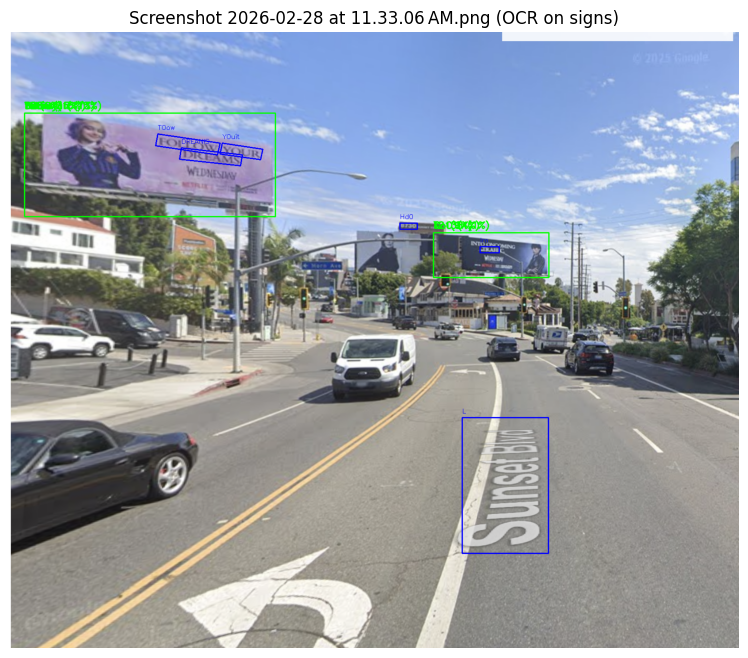

In [109]:
first_ocr = OCR_DIR / image_files[0].name
ocr_preview = cv2.imread(str(first_ocr))
ocr_preview = cv2.cvtColor(ocr_preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(ocr_preview)
plt.axis("off")
plt.title(f"{image_files[0].name} (OCR on signs)")
plt.show()

## Cell 17 — Load CLIP Model

In [110]:
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL = "openai/clip-vit-large-patch14"
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL).to(device)
clip_model.eval()

# Categories to classify — customize these as needed
SIGN_LABELS = [
    "left turn arrow",
    "right turn arrow",
    "straight ahead arrow",
    "U-turn arrow",
    "merge arrow",
    "two-way arrow",
    "stop sign",
    "yield sign",
    "speed limit sign",
    "no entry sign",
    "pedestrian crossing sign",
    "parking sign",
    "one way sign",
    "do not enter sign",
    "construction warning sign",
    "school zone sign",
    "no parking sign",
    "road name sign",
    "highway exit sign",
    "information sign",
    "blank or unreadable sign",
]

ROAD_MARKING_LABELS = [
    "left turn arrow on road",
    "right turn arrow on road",
    "straight ahead arrow on road",
    "left and straight arrow on road",
    "right and straight arrow on road",
    "crosswalk markings",
    "stop line",
    "lane divider",
    "bike lane marking",
    "speed limit marking on road",
    "plain road surface",
]

print(f"CLIP loaded on {device}.")

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 1196.20it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded on mps.


## Cell 18 — Classify Signs & Road Markings with CLIP

In [111]:
def classify_crop(crop_pil, labels):
    """Run CLIP zero-shot classification on a PIL image crop."""
    text_prompts = [f"a photo of a {label}" for label in labels]
    inputs = clip_processor(text=text_prompts, images=crop_pil, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        outputs = clip_model(**inputs)
    logits = outputs.logits_per_image[0]
    probs = logits.softmax(dim=0).cpu().numpy()
    top_idx = probs.argsort()[::-1][:3]
    return [(labels[i], float(probs[i])) for i in top_idx]

# Sign classes (signs) + lane markings (road arrows)
SIGN_IDS = {32, 35, 46, 49, 50}       # Banner, Billboard, Traffic Sign Frame, Back, Front
ROAD_MARKING_IDS = {23, 24}            # Lane Marking - Crosswalk, Lane Marking - General

CLIP_DIR = Path("clip_results")
CLIP_DIR.mkdir(exist_ok=True)

for img_path in image_files:
    mask_path = MASKS_MV_DIR / img_path.name
    mask_img = np.array(Image.open(mask_path))
    original = cv2.imread(str(img_path))
    original_pil = Image.open(img_path).convert("RGB")
    img_h, img_w = original.shape[:2]

    annotated = original.copy()
    print(f"\n{'='*60}")
    print(f"{img_path.name}")
    print(f"{'='*60}")

    # --- Process sign regions ---
    sign_seg = np.zeros(mask_img.shape[:2], dtype=np.uint8)
    for cls_id in SIGN_IDS:
        color = MAPILLARY_PALETTE[cls_id]
        match = np.all(mask_img == color, axis=-1)
        sign_seg[match] = cls_id

    sign_mask = np.isin(sign_seg, list(SIGN_IDS))
    if sign_mask.any():
        sign_uint8 = sign_mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(sign_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        print(f"\nSigns: {len(contours)} region(s)")

        for j, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)
            if w < 15 or h < 15:
                continue

            pad = max(w, h) // 4
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(img_w, x + w + pad), min(img_h, y + h + pad)
            crop = original_pil.crop((x1, y1, x2, y2))

            results = classify_crop(crop, SIGN_LABELS)
            top_label, top_conf = results[0]
            print(f"  Region {j+1} ({w}x{h}): {top_label} ({top_conf:.0%})")
            for label, conf in results[1:]:
                print(f"    also: {label} ({conf:.0%})")

            cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(annotated, f"{top_label} ({top_conf:.0%})", (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
        print("\nSigns: none detected")

    # --- Process road marking regions ---
    road_seg = np.zeros(mask_img.shape[:2], dtype=np.uint8)
    for cls_id in ROAD_MARKING_IDS:
        color = MAPILLARY_PALETTE[cls_id]
        match = np.all(mask_img == color, axis=-1)
        road_seg[match] = cls_id

    road_mask = np.isin(road_seg, list(ROAD_MARKING_IDS))
    if road_mask.any():
        road_uint8 = road_mask.astype(np.uint8) * 255
        contours, _ = cv2.findContours(road_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        print(f"\nRoad markings: {len(contours)} region(s)")

        for j, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)
            if w < 20 or h < 20:
                continue

            pad = max(w, h) // 4
            x1, y1 = max(0, x - pad), max(0, y - pad)
            x2, y2 = min(img_w, x + w + pad), min(img_h, y + h + pad)
            crop = original_pil.crop((x1, y1, x2, y2))

            results = classify_crop(crop, ROAD_MARKING_LABELS)
            top_label, top_conf = results[0]
            print(f"  Region {j+1} ({w}x{h}): {top_label} ({top_conf:.0%})")
            for label, conf in results[1:]:
                print(f"    also: {label} ({conf:.0%})")

            cv2.rectangle(annotated, (x, y), (x+w, y+h), (0, 200, 255), 2)
            cv2.putText(annotated, f"{top_label} ({top_conf:.0%})", (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)
    else:
        print("\nRoad markings: none detected")

    cv2.imwrite(str(CLIP_DIR / img_path.name), annotated)

print(f"\nAnnotated images saved to {CLIP_DIR}/")


Screenshot 2026-02-28 at 11.33.06 AM.png

Signs: 11 region(s)
  Region 1 (48x28): blank or unreadable sign (18%)
    also: no parking sign (18%)
    also: right turn arrow (7%)
  Region 4 (36x49): left turn arrow (42%)
    also: right turn arrow (17%)
    also: yield sign (8%)
  Region 5 (15x26): yield sign (24%)
    also: blank or unreadable sign (16%)
    also: straight ahead arrow (9%)
  Region 6 (107x36): road name sign (89%)
    also: one way sign (2%)
    also: merge arrow (2%)
  Region 7 (44x46): blank or unreadable sign (37%)
    also: yield sign (11%)
    also: stop sign (8%)
  Region 9 (265x103): merge arrow (53%)
    also: straight ahead arrow (14%)
    also: do not enter sign (5%)
  Region 10 (103x61): blank or unreadable sign (40%)
    also: school zone sign (27%)
    also: road name sign (13%)
  Region 11 (576x238): road name sign (19%)
    also: school zone sign (17%)
    also: straight ahead arrow (16%)

Road markings: 17 region(s)
  Region 1 (450x224): right and strai

## Cell 19 — Preview CLIP Results

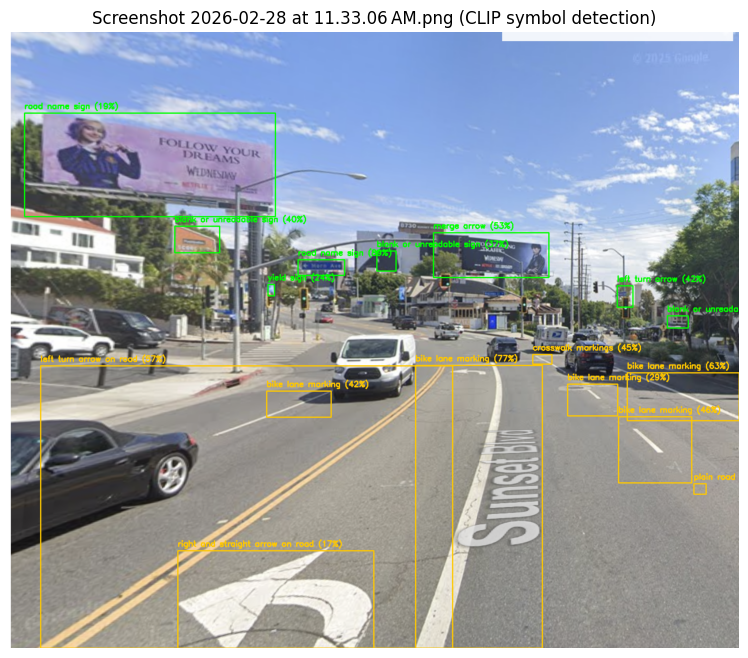

In [112]:
first_clip = CLIP_DIR / image_files[0].name
clip_preview = cv2.imread(str(first_clip))
clip_preview = cv2.cvtColor(clip_preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(clip_preview)
plt.axis("off")
plt.title(f"{image_files[0].name} (CLIP symbol detection)")
plt.show()

## Cell 20 — Save Isolated CLIP Detections

In [ ]:
CLIP_ISOLATED_DIR = Path("clip_isolated")
CLIP_ISOLATED_DIR.mkdir(exist_ok=True)

ALL_DETECT_IDS = SIGN_IDS | ROAD_MARKING_IDS  # {32, 35, 46, 49, 50, 23, 24}

for img_path in image_files:
    # Always save as .png for transparency support
    out_path = CLIP_ISOLATED_DIR / (img_path.stem + ".png")
    if out_path.exists():
        print(f"{out_path.name} — exists, skipping.")
        continue

    mask_img = np.array(Image.open(MASKS_MV_DIR / img_path.name))
    original = cv2.imread(str(img_path))

    # Build a binary mask of all sign + road marking pixels
    keep_mask = np.zeros(mask_img.shape[:2], dtype=bool)
    for cls_id in ALL_DETECT_IDS:
        color = MAPILLARY_PALETTE[cls_id]
        keep_mask |= np.all(mask_img == color, axis=-1)

    # Create RGBA image: RGB from original, alpha from mask
    b, g, r = cv2.split(original)
    alpha = (keep_mask.astype(np.uint8) * 255)
    rgba = cv2.merge([b, g, r, alpha])

    cv2.imwrite(str(out_path), rgba)
    print(f"{out_path.name} — saved (transparent PNG).")

print(f"\nIsolated images saved to {CLIP_ISOLATED_DIR}/")

## Cell 21 — Preview Isolated CLIP Detections

In [ ]:
fig, axes = plt.subplots(1, len(image_files), figsize=(14 * len(image_files), 8))
if len(image_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_files):
    png_path = CLIP_ISOLATED_DIR / (img_path.stem + ".png")
    img = cv2.imread(str(png_path), cv2.IMREAD_UNCHANGED)
    img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{img_path.stem} (isolated, transparent)")

plt.tight_layout()
plt.show()

## Cell 22 — Layered Composite

In [ ]:
def create_layered_image(img_path, mask_opacity=1.0):
    """
    Create a layered composite image.
    Layer 1: Original image (base)
    Layer 2: Mapillary segmentation mask at mask_opacity (0.0–1.0)
    Layer 3: CLIP isolated detections (full opacity, transparent regions pass through)
    """
    # Layer 1 — original image
    original = cv2.imread(str(img_path)).astype(np.float32)

    # Layer 2 — Mapillary mask blended at mask_opacity
    mask = cv2.imread(str(MASKS_MV_DIR / img_path.name)).astype(np.float32)
    composite = original * (1 - mask_opacity) + mask * mask_opacity

    # Layer 3 — CLIP isolated (transparent PNG) composited on top
    clip_path = CLIP_ISOLATED_DIR / (img_path.stem + ".png")
    clip_rgba = cv2.imread(str(clip_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
    clip_rgb = clip_rgba[:, :, :3]
    clip_alpha = clip_rgba[:, :, 3:] / 255.0  # normalize alpha to 0–1

    composite = composite * (1 - clip_alpha) + clip_rgb * clip_alpha

    return np.clip(composite, 0, 255).astype(np.uint8)


LAYERED_DIR = Path("layered")
LAYERED_DIR.mkdir(exist_ok=True)

MASK_OPACITY = 1.0

for img_path in image_files:
    out_path = LAYERED_DIR / img_path.name
    if out_path.exists():
        print(f"{img_path.name} — exists, skipping.")
        continue

    result = create_layered_image(img_path, mask_opacity=MASK_OPACITY)
    cv2.imwrite(str(out_path), result)
    print(f"{img_path.name} — saved (opacity={MASK_OPACITY:.0%}).")

print(f"\nLayered images saved to {LAYERED_DIR}/")

# Display results
fig, axes = plt.subplots(1, len(image_files), figsize=(14 * len(image_files), 8))
if len(image_files) == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_files):
    img = cv2.imread(str(LAYERED_DIR / img_path.name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{img_path.stem} (layered, mask {MASK_OPACITY:.0%})")

plt.tight_layout()
plt.show()